In [1]:
import optuna

study = optuna.load_study(
    study_name='pretrained_v1',
    storage='sqlite:///../optuna_pretrained_v1.db'
)

# Completed trials only
df = study.trials_dataframe()
df_done = df[df['state'] == 'COMPLETE'].sort_values('value')

# Parameter importance
optuna.visualization.plot_param_importances(study).show()

# Optimization history
optuna.visualization.plot_optimization_history(study).show()

# Slice plot (each param vs objective)
optuna.visualization.plot_slice(study).show()

In [2]:
import sys
sys.path.append('..')

from Pretrain import pretrain
from torch import nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import json

from model_stuff import Predictor
from Rollout import train_rollout
from SingleModel import SingleModel


best = study.best_params
print(json.dumps(best, indent=2))


{
  "lag": 150,
  "n_pretrain_epochs": 20,
  "lr_pretrain": 0.001962635090084424,
  "train_horizon": 120,
  "train_steps": 200,
  "lr_rollout": 9.945405230349677e-05,
  "transition_prob": 0.7,
  "dropout": 0.027353153688391404,
  "loss": "mse",
  "transition_config": "200_12"
}


In [3]:
X_df = pd.read_csv('../../data/CombinedDatasetLongUnsmooth.csv')
X_df = X_df.drop(columns=['AMOC']).rename(columns={'AMOC_40N': 'AMOC'})
model_vars   = ['AMOC', 'SFWF', 'PD_200m']
feature_cols = target_cols = model_vars
train_cut_1, train_cut_2 = 12500, 18500
train_idx = list(range(train_cut_1)) + list(range(train_cut_2, len(X_df)))


y_scalers = {}
X_scaled  = X_df[model_vars].copy().astype(float)
for var in model_vars:
    sc = StandardScaler().fit(X_df[var].values[train_idx].reshape(-1, 1))
    X_scaled[var] = sc.transform(X_df[var].values.reshape(-1, 1))
    y_scalers[var] = sc


x_scaler = StandardScaler().fit(X_df[feature_cols].values[train_idx])

In [ ]:
model = Predictor(n_features=3, hidden_size=64, num_layers=1, dropout=best['dropout'], output_size=3)

pretrain(X_scaled, train_cut_1, train_cut_2, model,
         feature_cols, target_cols,
         lag=150, horizon=1,        
         n_epochs=10, batch_size=64,
         lr=best['lr_pretrain'], loss_fn=nn.MSELoss())

transition_prob = 0.7
threshold = 9
amoc_std = y_scalers['AMOC'].scale_[0]
threshold_scaled = threshold / amoc_std
search_ahead = 200


train_rollout(X_scaled, train_cut_1, train_cut_2, transition_prob, threshold_scaled,
              search_ahead, model, feature_cols, target_cols,
              train_steps=200, lag=150, train_horizon=120, loss_fn=nn.MSELoss(), lr=best['lr_rollout'])


              
single = SingleModel.from_trained(model, x_scaler, y_scalers)

Epoch 10/10  loss: 0.0326


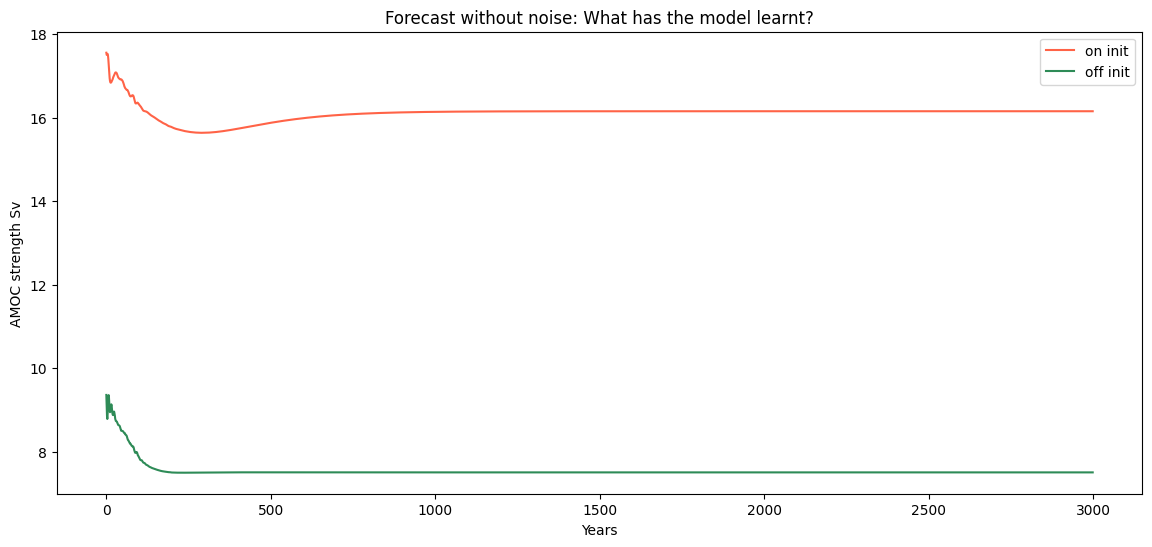

In [46]:
start_idx_off = 5100
start_idx_on = 6600
steps = 3000

preds_on  = single.predict(X_df, start_idx_on, feature_cols, target_cols, lag=100, steps=steps, threshold=14, rho=0.9, k=0.)
preds_off  = single.predict(X_df, start_idx_off, feature_cols, target_cols, lag=100, steps=steps, threshold=14, rho=0.9, k=0.0)

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, preds_on['AMOC'], label = 'on init', color = '#FF6347')
plt.plot(x, preds_off['AMOC'], label = 'off init', color = '#2E8B57')
plt.title('Forecast without noise: What has the model learnt?')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
plt.legend()

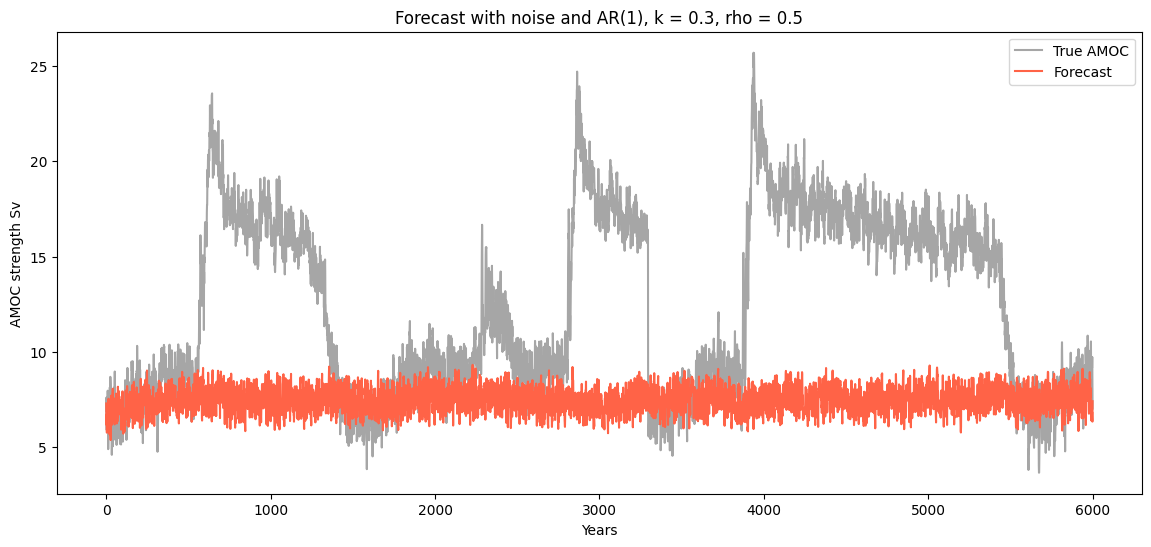

In [45]:
start_idx_on = train_cut_1
steps = train_cut_2 - train_cut_1

preds  = single.predict(X_df, start_idx_on, feature_cols, target_cols, lag=100, steps=steps, threshold=14, rho=0.2, k=0.01)

plt.figure(figsize=(14,6))

x = np.arange(train_cut_2-train_cut_1)

plt.plot(x, X_df['AMOC'][train_cut_1:train_cut_2], label = 'True AMOC', color = 'grey', alpha = 0.7)
plt.plot(x, preds['AMOC'], label = 'Forecast', color = '#FF6347')
plt.title('Forecast with noise and AR(1), k = 0.3, rho = 0.5')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
plt.legend()